# Batch Segmentation for Remote Sensing Imagery with SAM 3

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/segment-geospatial/blob/main/docs/examples/sam3_batch_segmentation.ipynb)

This notebook demonstrates how to do batch segmentation for remote sensing imagery with SAM 3.

## Installation

First, make sure you have the required dependencies installed:

In [1]:
#%pip install "segment-geospatial[samgeo3]"

## Import Libraries


In [2]:
import leafmap
from samgeo import SamGeo3, download_file

In [17]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random


## Download Sample Data

Let's download sample satellite images covering the University of California, Berkeley, for testing:


In [ ]:
test_images_dir = "/media/data/building_instance_tamu/test/images"
output_dir = "/media/data/building_instance_tamu/sam3/test"

mask_out = Path(output_dir) / "masks"
ann_out = Path(output_dir) / "annotations"
mask_out.mkdir(parents=True, exist_ok=True)
ann_out.mkdir(parents=True, exist_ok=True)

# Get all pre-disaster images
image_paths = sorted(Path(test_images_dir).glob("*_pre_disaster.png"))
image_paths = [str(p) for p in image_paths]

print(f"Found {len(image_paths)} pre-disaster images")

Found 933 pre-disaster images
  - guatemala-volcano_00000003_pre_disaster.png
  - guatemala-volcano_00000005_pre_disaster.png
  - guatemala-volcano_00000009_pre_disaster.png
  - guatemala-volcano_00000011_pre_disaster.png
  - guatemala-volcano_00000021_pre_disaster.png


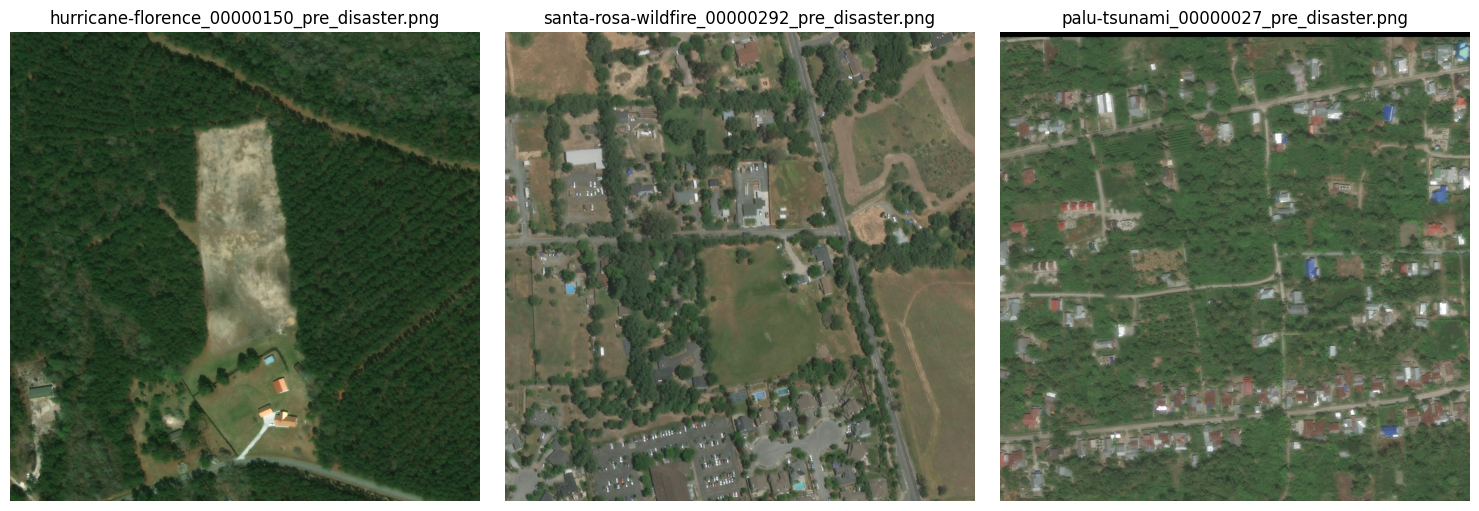

In [19]:
random_sample = True  # Set to True for random selection

if random_sample:
    # Randomly select 3 images
    sample_indices = random.sample(range(len(image_paths)), min(3, len(image_paths)))
    sample_paths = [image_paths[i] for i in sample_indices]
else:
    # Show first 3 images
    sample_paths = image_paths[:3]

fig, axes = plt.subplots(1, len(sample_paths), figsize=(15, 5))
if len(sample_paths) == 1:
    axes = [axes]  # Make it iterable for single image

for i, img_path in enumerate(sample_paths):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(Path(img_path).name)
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()

In [3]:
# image_paths = []
# for i in range(1, 5):
#     url = f"https://huggingface.co/datasets/giswqs/geospatial/resolve/main/uc_berkeley_{i}.tif"
#     image_path = download_file(url)
#     image_paths.append(image_path)

In [8]:
# This is for GEO information only
# m = leafmap.Map()
# for i, image_path in enumerate(image_paths):
#     m.add_raster(image_path, layer_name=f"image_{i + 1}")
# m

## Request access to SAM3

To use SAM3, you need to request access by filling out this form on Hugging Face: https://huggingface.co/facebook/sam3

Once you have access, uncomment the following code block and run it.

In [20]:
from huggingface_hub import login
login()

## Initialize SAM3

When initializing SAM3, you can choose the backend from "meta", or "transformers".

In [21]:
sam3 = SamGeo3(backend="meta", device=None, checkpoint_path=None, load_from_HF=True)

Using cuda device and meta backend


## Set the image batch

In [37]:
## Check and Clear GPU Memory
import torch
import gc

# Check current GPU memory
print("GPU Memory Status:")
print(f"Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

# Clear cache
torch.cuda.empty_cache()
gc.collect()

print("\nAfter clearing cache:")
print(f"Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

GPU Memory Status:
Allocated: 4.49 GB
Reserved: 5.81 GB

After clearing cache:
Allocated: 4.49 GB
Reserved: 5.81 GB



Processing image 1/933
File: guatemala-volcano_00000003_pre_disaster.png
Set 1 images for batch processing.
Processed 1 image(s), found 3 total object(s).
  Found 3 buildings
Saved 3 mask(s) for image 1 to /media/data/building_instance_tamu/sam3/test/masks/guatemala-volcano_00000003_pre_disaster_1.png
  Saved 1 mask files
Saved annotations to /media/data/building_instance_tamu/sam3/test/annotations/guatemala-volcano_00000003_pre_disaster_ann_1.png

Processing image 2/933
File: guatemala-volcano_00000005_pre_disaster.png
Set 1 images for batch processing.
  ERROR processing image: Boolean value of Tensor with no values is ambiguous

Processing image 3/933
File: guatemala-volcano_00000009_pre_disaster.png


Traceback (most recent call last):
  File "/tmp/ipykernel_504379/1901038438.py", line 24, in <module>
    sam3.generate_masks_batch("building", min_size=100)
  File "/media/gisense/xihan/geoai_sam/lib/python3.12/site-packages/samgeo/samgeo3.py", line 440, in generate_masks_batch
    result = self._filter_batch_result_by_size(result, min_size, max_size)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/media/gisense/xihan/geoai_sam/lib/python3.12/site-packages/samgeo/samgeo3.py", line 662, in _filter_batch_result_by_size
    if not result.get("masks"):
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Boolean value of Tensor with no values is ambiguous


Set 1 images for batch processing.
Processed 1 image(s), found 3 total object(s).
  Found 3 buildings
Saved 3 mask(s) for image 1 to /media/data/building_instance_tamu/sam3/test/masks/guatemala-volcano_00000009_pre_disaster_1.png
  Saved 1 mask files
Saved annotations to /media/data/building_instance_tamu/sam3/test/annotations/guatemala-volcano_00000009_pre_disaster_ann_1.png

Processing image 4/933
File: guatemala-volcano_00000011_pre_disaster.png
Set 1 images for batch processing.
  ERROR processing image: Boolean value of Tensor with no values is ambiguous

Processing image 5/933
File: guatemala-volcano_00000021_pre_disaster.png


Traceback (most recent call last):
  File "/tmp/ipykernel_504379/1901038438.py", line 24, in <module>
    sam3.generate_masks_batch("building", min_size=100)
  File "/media/gisense/xihan/geoai_sam/lib/python3.12/site-packages/samgeo/samgeo3.py", line 440, in generate_masks_batch
    result = self._filter_batch_result_by_size(result, min_size, max_size)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/media/gisense/xihan/geoai_sam/lib/python3.12/site-packages/samgeo/samgeo3.py", line 662, in _filter_batch_result_by_size
    if not result.get("masks"):
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Boolean value of Tensor with no values is ambiguous


Set 1 images for batch processing.
Processed 1 image(s), found 15 total object(s).
  Found 15 buildings
Saved 15 mask(s) for image 1 to /media/data/building_instance_tamu/sam3/test/masks/guatemala-volcano_00000021_pre_disaster_1.png
  Saved 1 mask files
Saved annotations to /media/data/building_instance_tamu/sam3/test/annotations/guatemala-volcano_00000021_pre_disaster_ann_1.png

Processing image 6/933
File: hurricane-florence_00000004_pre_disaster.png
Set 1 images for batch processing.
Processed 1 image(s), found 80 total object(s).
  Found 80 buildings
Saved 80 mask(s) for image 1 to /media/data/building_instance_tamu/sam3/test/masks/hurricane-florence_00000004_pre_disaster_1.png
  Saved 1 mask files
Saved annotations to /media/data/building_instance_tamu/sam3/test/annotations/hurricane-florence_00000004_pre_disaster_ann_1.png

Processing image 7/933
File: hurricane-florence_00000005_pre_disaster.png
Set 1 images for batch processing.
Processed 1 image(s), found 73 total object(s).
 

...

Traceback (most recent call last):
  File "/tmp/ipykernel_504379/1901038438.py", line 24, in <module>
    sam3.generate_masks_batch("building", min_size=100)
  File "/media/gisense/xihan/geoai_sam/lib/python3.12/site-packages/samgeo/samgeo3.py", line 440, in generate_masks_batch
    result = self._filter_batch_result_by_size(result, min_size, max_size)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/media/gisense/xihan/geoai_sam/lib/python3.12/site-packages/samgeo/samgeo3.py", line 662, in _filter_batch_result_by_size
    if not result.get("masks"):
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Boolean value of Tensor with no values is ambiguous


Set 1 images for batch processing.
Processed 1 image(s), found 54 total object(s).
  Found 54 buildings
Saved 54 mask(s) for image 1 to /media/data/building_instance_tamu/sam3/test/masks/hurricane-florence_00000184_pre_disaster_1.png
  Saved 1 mask files
Saved annotations to /media/data/building_instance_tamu/sam3/test/annotations/hurricane-florence_00000184_pre_disaster_ann_1.png

Processing image 49/933
File: hurricane-florence_00000186_pre_disaster.png
Set 1 images for batch processing.
Processed 1 image(s), found 6 total object(s).
  Found 6 buildings
Saved 6 mask(s) for image 1 to /media/data/building_instance_tamu/sam3/test/masks/hurricane-florence_00000186_pre_disaster_1.png
  Saved 1 mask files
Saved annotations to /media/data/building_instance_tamu/sam3/test/annotations/hurricane-florence_00000186_pre_disaster_ann_1.png

Processing image 50/933
File: hurricane-florence_00000187_pre_disaster.png
Set 1 images for batch processing.
Processed 1 image(s), found 34 total object(s).


Traceback (most recent call last):
  File "/tmp/ipykernel_504379/1901038438.py", line 24, in <module>
    sam3.generate_masks_batch("building", min_size=100)
  File "/media/gisense/xihan/geoai_sam/lib/python3.12/site-packages/samgeo/samgeo3.py", line 440, in generate_masks_batch
    result = self._filter_batch_result_by_size(result, min_size, max_size)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/media/gisense/xihan/geoai_sam/lib/python3.12/site-packages/samgeo/samgeo3.py", line 662, in _filter_batch_result_by_size
    if not result.get("masks"):
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Boolean value of Tensor with no values is ambiguous


Set 1 images for batch processing.
Processed 1 image(s), found 14 total object(s).
  Found 14 buildings
Saved 14 mask(s) for image 1 to /media/data/building_instance_tamu/sam3/test/masks/hurricane-florence_00000268_pre_disaster_1.png
  Saved 1 mask files
Saved annotations to /media/data/building_instance_tamu/sam3/test/annotations/hurricane-florence_00000268_pre_disaster_ann_1.png

Processing image 68/933
File: hurricane-florence_00000276_pre_disaster.png
Set 1 images for batch processing.
Processed 1 image(s), found 5 total object(s).
  Found 5 buildings
Saved 5 mask(s) for image 1 to /media/data/building_instance_tamu/sam3/test/masks/hurricane-florence_00000276_pre_disaster_1.png
  Saved 1 mask files
Saved annotations to /media/data/building_instance_tamu/sam3/test/annotations/hurricane-florence_00000276_pre_disaster_ann_1.png

Processing image 69/933
File: hurricane-florence_00000286_pre_disaster.png
Set 1 images for batch processing.
Processed 1 image(s), found 14 total object(s).


KeyboardInterrupt: 

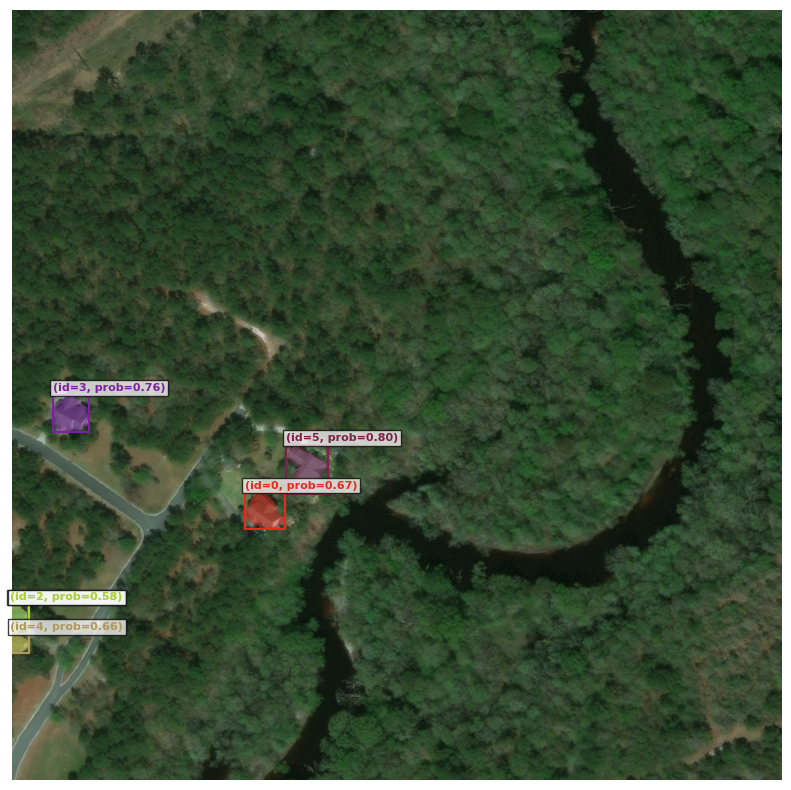

In [36]:
# Process images ONE AT A TIME to avoid memory issues
batch_size = 1  # Process one image at a time

for batch_idx in range(0, len(image_paths), batch_size):
    batch_paths = image_paths[batch_idx:batch_idx + batch_size]
    
    # Get the original filename without extension
    original_filename = Path(batch_paths[0]).stem  # e.g., "guatemala-volcano_00000003_pre_disaster"
    
    print(f"\n{'='*60}")
    print(f"Processing image {batch_idx + 1}/{len(image_paths)}")
    print(f"File: {Path(batch_paths[0]).name}")
    print(f"{'='*60}")
    
    try:
        # Clear GPU cache before processing
        torch.cuda.empty_cache()
        gc.collect()
        
        # Set batch
        sam3.set_image_batch(batch_paths)
        
        # Generate masks
        sam3.generate_masks_batch("building", min_size=100)
        
        # Check if masks were found
        if not sam3.batch_results or len(sam3.batch_results[0]['masks']) == 0:
            print(f"  WARNING: No buildings detected in this image")
            continue
        
        # Print results
        for i, result in enumerate(sam3.batch_results):
            print(f"  Found {len(result['masks'])} buildings")
        
        # Save masks with original filename
        saved_files = sam3.save_masks_batch(
            output_dir=f"{output_dir}/masks/",
            prefix=f"{original_filename}",
            unique=True
        )
        
        print(f"  Saved {len(saved_files)} mask files")
        
        # Save visualizations only if masks exist
        if len(sam3.batch_results[0]['masks']) > 0:
            sam3.show_anns_batch(
                output_dir=f"{output_dir}/annotations/",
                prefix=f"{original_filename}_ann",
                dpi=150
            )
        
    except Exception as e:
        print(f"  ERROR processing image: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*60}")
print("All images processed!")
print(f"{'='*60}")

In [ ]:
# sam3.set_image_batch(image_paths)

OutOfMemoryError: CUDA out of memory. Tried to allocate 10.60 GiB. GPU 0 has a total capacity of 47.53 GiB of which 532.56 MiB is free. Process 480399 has 12.51 GiB memory in use. Process 500000 has 6.32 GiB memory in use. Process 501532 has 5.73 GiB memory in use. Process 501441 has 7.87 GiB memory in use. Including non-PyTorch memory, this process has 14.56 GiB memory in use. Of the allocated memory 14.16 GiB is allocated by PyTorch, and 106.44 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Generate masks with text prompt

Generate masks for all images with a text prompt

In [ ]:
# sam3.generate_masks_batch("building", min_size=100)

Processed 4 image(s), found 174 total object(s).


In [ ]:
# # Access results for each image
# for i, result in enumerate(sam3.batch_results):
#     print(f"Image {i + 1}: Found {len(result['masks'])} objects")
#     # result contains: masks, boxes, scores, image, source

Image 1: Found 46 objects
Image 2: Found 50 objects
Image 3: Found 64 objects
Image 4: Found 14 objects


## Show results

In [ ]:
# Visualize all annotations in a grid
sam3.show_anns_batch(ncols=2, show_bbox=True, show_score=True)

![](https://github.com/user-attachments/assets/0c4f0b4b-4104-4a43-9173-ab76e0d2d71a)

## Save results

In [ ]:
sam3.show_anns_batch(output_dir="output/annotations/", prefix="ann", dpi=300)

In [ ]:
# Save all masks to disk
saved_files = sam3.save_masks_batch(
    output_dir="output/", prefix="building_mask", unique=True
)

## Vecterization

In [39]:
%pip install geoai-py

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached contextily-1.7.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached datasets-4.4.1-py3-none-any.whl.metadata (19 kB)
  Using cached ever_beta-0.5.3-py3-none-any.whl.metadata (18 kB)
  Using cached jupyter_server_proxy-4.4.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached mapclassify-2.10.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached overturemaps-0.18.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached planetary_computer-1.0.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached rioxarray-0.20.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached torchgeo-0.8.0-py3-none-any.whl.metadata (18 kB)
  Using cached torchinfo-1.8.0-py3-none-any.whl.metadata (21 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached fsspec-2025.10.0-py3-none-any.whl.metadata (10 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.

In [2]:
import json, uuid
import numpy as np
from PIL import Image
import rasterio
import geoai
from shapely.geometry import Point
from pathlib import Path

def vectorize_sam3_masks(masks_dir, output_dir, epsilon=2):
    masks_dir = Path(masks_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    mask_files = sorted([p for p in masks_dir.glob("*.tif") if "_scores" not in p.name])

    print(f"Processing {len(mask_files)} mask files...")
    for mask_path in mask_files:
        score_path = mask_path.with_name(mask_path.stem + "_scores.tif")
        if not score_path.exists():
            print(f"  ⚠️ Missing score file for {mask_path.name}, skipping.")
            continue

        print(f"Processing: {mask_path.name}")
        temp_geojson = output_dir / f"temp_{mask_path.stem}.geojson"

        try:
            gdf = geoai.orthogonalize(str(mask_path), str(temp_geojson), epsilon=epsilon)
            if gdf is None or len(gdf) == 0:
                print(f"  ⚠️ No buildings detected in {mask_path.name}")
                continue

            with rasterio.open(mask_path) as msrc, rasterio.open(score_path) as ssrc:
                mask_arr = msrc.read(1)
                score_arr = ssrc.read(1)

            features = []
            for _, row in gdf.iterrows():
                geom = row.geometry
                mask_id = int(mask_arr[msrc.index(*geom.centroid.coords[0])])
                if mask_id == 0:
                    mask_id = int(np.bincount(
                        mask_arr[msrc.window(*geom.bounds).round().astype(int)].ravel()
                    ).argmax())

                prob = float(score_arr[mask_arr == mask_id].mean()) if (mask_arr == mask_id).any() else None

                features.append({
                    "properties": {
                        "feature_type": "building",
                        "uid": str(uuid.uuid4()),
                        "label": mask_id,
                        "prob": prob,
                    },
                    "wkt": geom.wkt,
                })

            mask_img = np.array(Image.open(mask_path))
            output_json = {
                "features": {"xy": features, "lng_lat": []},
                "metadata": {
                    "original_width": mask_img.shape[1],
                    "original_height": mask_img.shape[0],
                    "width": mask_img.shape[1],
                    "height": mask_img.shape[0],
                    "img_name": mask_path.stem + ".png",
                },
            }

            out_path = output_dir / f"{mask_path.stem}_prediction.json"
            with open(out_path, "w") as f:
                json.dump(output_json, f, indent=2)

            print(f"  ✅ Saved {len(features)} buildings to {out_path.name}")

        except Exception as e:
            print(f"  ❌ Error processing {mask_path.name}: {e}")
        finally:
            if temp_geojson.exists():
                temp_geojson.unlink()

    print("\n✅ All predictions vectorized!")

# Run
vectorize_sam3_masks(
    masks_dir="/media/data/building_instance_tamu/sam3/test/masks",
    output_dir="/media/data/building_instance_tamu/sam3/test/labels",
    epsilon=2,
)

Processing 657 mask files...
Processing: guatemala-volcano_00000003_pre_disaster.tif
Processing 4 features...


Converting features: 100%|██████████| 4/4 [00:00<00:00, 68.10shape/s]

Saving to /media/data/building_instance_tamu/sam3/test/labels/temp_guatemala-volcano_00000003_pre_disaster.geojson...
Done!
  ✅ Saved 3 buildings to guatemala-volcano_00000003_pre_disaster_prediction.json
Processing: guatemala-volcano_00000009_pre_disaster.tif
Processing 4 features...



Converting features: 100%|██████████| 4/4 [00:00<00:00, 115.81shape/s]


Saving to /media/data/building_instance_tamu/sam3/test/labels/temp_guatemala-volcano_00000009_pre_disaster.geojson...
Done!
  ✅ Saved 3 buildings to guatemala-volcano_00000009_pre_disaster_prediction.json
Processing: guatemala-volcano_00000021_pre_disaster.tif
Processing 17 features...


...

Saving to /media/data/building_instance_tamu/sam3/test/labels/temp_socal-fire_00001372_pre_disaster.geojson...
Done!
  ✅ Saved 35 buildings to socal-fire_00001372_pre_disaster_prediction.json
Processing: socal-fire_00001378_pre_disaster.tif
Processing 50 features...


Converting features: 100%|██████████| 50/50 [00:00<00:00, 161.03shape/s]


Saving to /media/data/building_instance_tamu/sam3/test/labels/temp_socal-fire_00001378_pre_disaster.geojson...
Done!
  ✅ Saved 36 buildings to socal-fire_00001378_pre_disaster_prediction.json
Processing: socal-fire_00001400_pre_disaster.tif
Processing 45 features...


Converting features: 100%|██████████| 45/45 [00:00<00:00, 279.11shape/s]

Saving to /media/data/building_instance_tamu/sam3/test/labels/temp_socal-fire_00001400_pre_disaster.geojson...
Done!
  ✅ Saved 42 buildings to socal-fire_00001400_pre_disaster_prediction.json

✅ All predictions vectorized!
